In [120]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
# Also add notebook_modules/ so `from twopoint_lockin import ...` etc. work
# without per-notebook sys.path tweaks. The five .py modules used by these
# notebooks live there now (lockin_extensions, multipoint_lockin_program,
# nv_magnetometry_analysis, odmr_sensitivity, twopoint_lockin).
_nb_modules_dir = PROJECT_ROOT / "notebook_modules"
if _nb_modules_dir.exists() and str(_nb_modules_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_modules_dir))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: C:\Users\Thoma\Downloads\nv-compact-magnetometer


# Import and setup

In [121]:
%load_ext autoreload
%matplotlib inline
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit

# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '192.168.0.103'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

QICK library version mismatch: 0.2.386 remote (the board), 0.2.388 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Connected to RFSoC at 192.168.0.103


In [122]:
default_config = qd.NVConfiguration()

# ADC channel: 0 or 1 (run diagnostic above if unsure which has your photodiode)
# 0 for ADC_D and 1 for ADC_C
default_config.adc_channel = 0
default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 500
default_config.readout_integration_tus = 213  # max ~106.7 µs; auto-sets _treg and _tns

print("Default configuration:")
print(f"  ADC channel:     {default_config.adc_channel}")
print(f"  MW channel:      {default_config.mw_channel}")
print(f"  MW gain:         {default_config.mw_gain}")
print(f"  Relax delay:     {default_config.relax_delay_tns:.0f} ns")
print(f"  Readout int.:    {default_config.readout_integration_tus:.2f} µs  ({default_config.readout_integration_treg} treg)")

Default configuration:
  ADC channel:     0
  MW channel:      1
  MW gain:         5000
  Relax delay:     501 ns
  Readout int.:    213.00 µs  (65434 treg)


# ODMR

In [637]:
# =============================================================================
# ODMR sweep — edit ALL parameters below, then run this cell once.
# Builds config, runs LockinODMR, saves full sweep to CSV and a signal-only PNG.
# =============================================================================
import pandas as pd
from pathlib import Path
from datetime import datetime
import importlib

from IPython.display import FileLink, display

# --- Microwave & timing ---
ODMR_MW_GAIN = 15000              # 0–32767; ↑ if contrast weak, ↓ if saturated
ODMR_PRE_INIT = True             # MW+laser prepulse before sweep
ODMR_REPS = 10                   # averages per frequency point
ODMR_RELAX_DELAY_TREG = 1000     # delay register units between MW on/off segments 100000 

# --- ADC readout integration (photodiode PL averaging time) ---
ODMR_READOUT_INTEGRATION_TUS =  213  # or set e.g. 50.0 (microseconds)

# --- Frequency sweep (MHz) ---
MW_FREQ_START_MHZ = 2680
MW_FREQ_STOP_MHZ = 3070
MW_FREQ_STEP_MHZ = 1             # step size (MHz); narrow range once peaks are known
# Instead of delta, you can use a fixed point count, e.g.:
#   config_odmr.add_linear_sweep("mw", "fMHz", start=2700, stop=3000, nsweep_points=301)
# (then comment out the add_linear_sweep call in the build block below and paste there)

# --- Data export ---
SAVE_ODMR_CSV = True              # save full sweep: MW on / MW off / contrast
SAVE_ODMR_SIGNAL_PNG = True       # save a signal-only ODMR plot to the same folder
# Optional tag appended to the filename, e.g. "0.44VBias_1" ->
# odmr_sweep_20260707_112045_0.44VBias_1.csv. Leave "" for a plain timestamped name.
# This replaces renaming the file by hand after each run.
ODMR_CSV_LABEL = ""

# --- If reference should be flat but shows dips: try True (explicit low-gain pulse in ref. window) ---
ODMR_REFERENCE_ZERO_GAIN_PULSE = False
ODMR_REFERENCE_PULSE_GAIN = 1       # use 1 if gain 0 faults; increase only if needed
# --- Only if reference is flat and signal is not (mis-labeled shots), try True ---
ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE = False

# --- Build configuration (inherits adc_channel, mw_channel, laser from default_config) ---
config_odmr = copy(default_config)
config_odmr.odmr_reference_zero_gain_pulse = ODMR_REFERENCE_ZERO_GAIN_PULSE
config_odmr.odmr_reference_pulse_gain = ODMR_REFERENCE_PULSE_GAIN
config_odmr.odmr_lockin_swap_signal_reference = ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE
config_odmr.readout_integration_tus = ODMR_READOUT_INTEGRATION_TUS
config_odmr.mw_gain = ODMR_MW_GAIN
config_odmr.pre_init = ODMR_PRE_INIT
config_odmr.reps = ODMR_REPS
config_odmr.relax_delay_treg = ODMR_RELAX_DELAY_TREG
config_odmr.add_linear_sweep(
    "mw", "fMHz",
    start=MW_FREQ_START_MHZ,
    stop=MW_FREQ_STOP_MHZ,
    delta=MW_FREQ_STEP_MHZ,
)

print("ODMR configuration:")
print(f"  ADC channel: {config_odmr.adc_channel}  MW channel: {config_odmr.mw_channel}  gain: {config_odmr.mw_gain}")
print(f"  Sweep: {config_odmr.mw_start_fMHz:.3f} → {config_odmr.mw_end_fMHz:.3f} MHz  ({config_odmr.nsweep_points} pts)")
print(f"  reps: {config_odmr.reps}  est. time: {qd.LockinODMR(config_odmr).total_time():.1f} s")

prog_odmr = qd.LockinODMR(config_odmr)
d = prog_odmr.acquire(progress=True)
print("Acquisition done.")

if SAVE_ODMR_CSV or SAVE_ODMR_SIGNAL_PNG:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    # Save ODMR exports to the categorized data store under PROJECT_ROOT/data/odmr_sweeps/
    # so every run lands in one place regardless of which folder the notebook is launched
    # from, and so Lockin_module / Twopoint_Lockin_module find CSVs with their
    # "newest odmr_sweep_*.csv" fallback. PROJECT_ROOT is set by project_root_setup.
    odmr_sweep_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
    odmr_sweep_dir.mkdir(parents=True, exist_ok=True)
    # Keep the label filesystem-safe so it cannot inject a path separator.
    _label = "".join(ch for ch in str(ODMR_CSV_LABEL).strip().replace(" ", "_")
                     if ch.isalnum() or ch in "._-")
    _suffix = f"_{_label}" if _label else ""

if SAVE_ODMR_CSV:
    odmr_df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    csv_path = odmr_sweep_dir / f"odmr_sweep_{ts}{_suffix}.csv"
    odmr_df.to_csv(csv_path, index=False)
    LAST_ODMR_CSV = csv_path
    LAST_ODMR_DF = odmr_df.copy()
    print(f"CSV: {len(odmr_df)} rows → {csv_path.resolve()}")
    display(FileLink(str(csv_path)))

if SAVE_ODMR_SIGNAL_PNG:
    signal_png_path = odmr_sweep_dir / f"odmr_signal_{ts}{_suffix}.png"
    signal_fig, signal_ax = plt.subplots(figsize=(10, 4))
    signal_ax.plot(
        np.asarray(d.frequencies, dtype=float),
        np.asarray(d.signal, dtype=float),
        color="steelblue",
        linewidth=1.4,
    )
    signal_ax.set_xlabel("Frequency (MHz)")
    signal_ax.set_ylabel("MW-on PL (ADC units)")
    signal_ax.set_title("ODMR Signal")
    signal_ax.grid(True, alpha=0.3)
    signal_fig.tight_layout()
    signal_fig.savefig(signal_png_path, dpi=200, bbox_inches="tight")
    plt.close(signal_fig)
    LAST_ODMR_SIGNAL_PNG = signal_png_path
    print(f"Signal PNG: {signal_png_path.resolve()}")
    display(FileLink(str(signal_png_path)))


Requested 2680 to 3070 by 1
Instead using 2679.9999996185306 to 3069.9998508453373 by 0.9999996185302735 in 391 steps
ODMR configuration:
  ADC channel: 0  MW channel: 1  gain: 15000
  Sweep: 2680.000 → 3070.000 MHz  (391 pts)
  reps: 10  est. time: 1.7 s


100%|██████████| 3910/3910 [00:00<00:00, 585453.69it/s]

Acquisition done.
CSV: 391 rows → C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\odmr_sweeps\odmr_sweep_20260814_143247.csv


C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\odmr_sweeps\odmr_sweep_20260814_143247.csv

Signal PNG: C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\odmr_sweeps\odmr_signal_20260814_143247.png


C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\odmr_sweeps\odmr_signal_20260814_143247.png

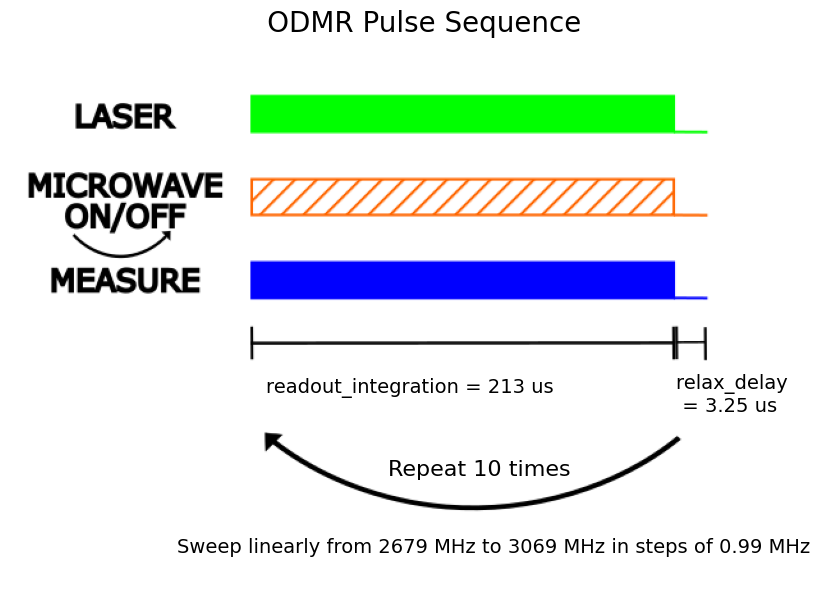

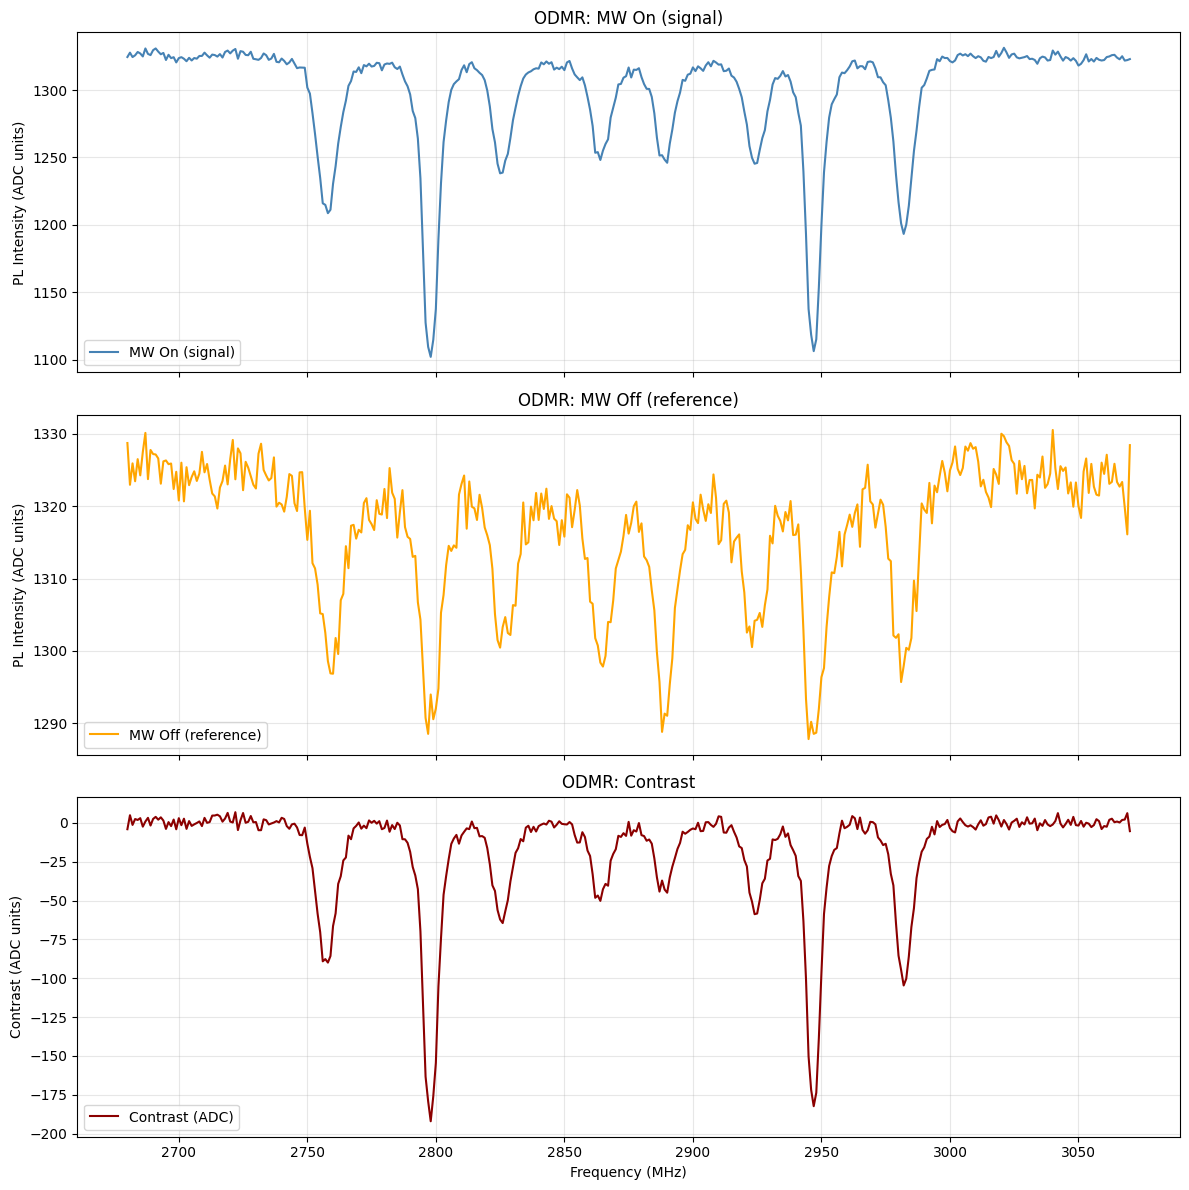

In [638]:
qd.LockinODMR.plot_sequence(config_odmr)

# Plot ODMR spectrum with subplots for MW On, MW Off, and Contrast
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot MW On (signal)
axes[0].plot(d.frequencies, d.signal, label='MW On (signal)', color='steelblue')
axes[0].set_ylabel('PL Intensity (ADC units)')
axes[0].set_title('ODMR: MW On (signal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MW Off (reference)
axes[1].plot(d.frequencies, d.reference, label='MW Off (reference)', color='orange')
axes[1].set_ylabel('PL Intensity (ADC units)')
axes[1].set_title('ODMR: MW Off (reference)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot Contrast
axes[2].plot(d.frequencies, d.contrast, label='Contrast (ADC)', color='darkred')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('Contrast (ADC units)')
axes[2].set_title('ODMR: Contrast')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

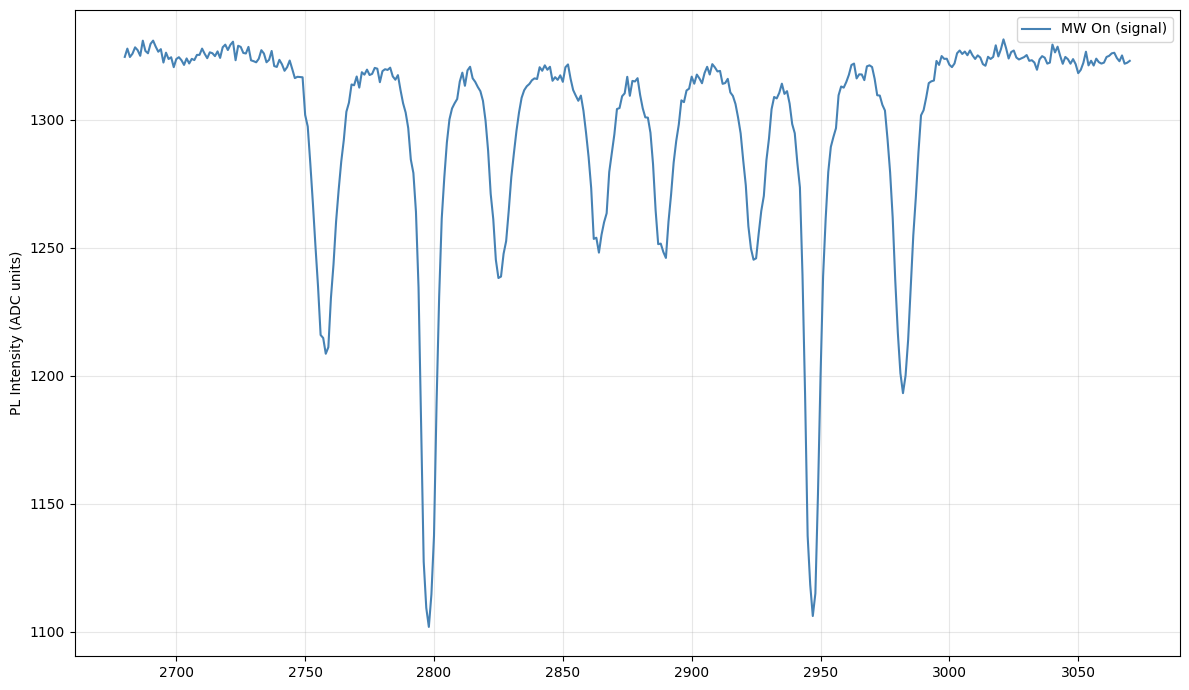

In [639]:
# Plot ODMR spectrum (Signal and Reference only)
fig, ax = plt.subplots(figsize=(12, 7), sharex=True)

ax.plot(d.frequencies, d.signal,    label='MW On (signal)',    color='steelblue')
ax.set_ylabel('PL Intensity (ADC units)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

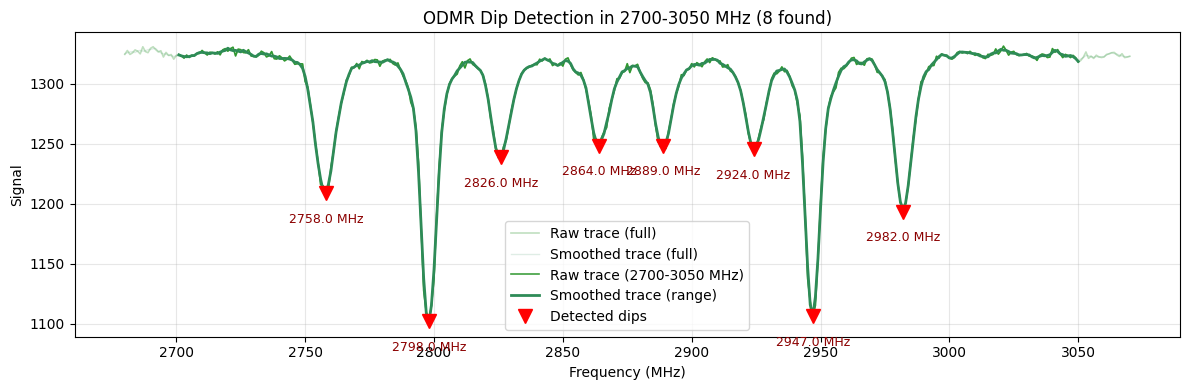

Trace source: Current acquisition (`d.reference`)
Analyzed range: 2700 to 3050 MHz
Using column 1 as x and column 3 as y when a CSV path is provided.
Prominence threshold used: 17.09 ADC
Detected ODMR dips in selected range:
  Dip 1: 2758.00 MHz  (1208.6670 ADC)
  Dip 2: 2798.00 MHz  (1101.9863 ADC)
  Dip 3: 2826.00 MHz  (1238.8009 ADC)
  Dip 4: 2864.00 MHz  (1248.1666 ADC)
  Dip 5: 2889.00 MHz  (1248.4059 ADC)
  Dip 6: 2924.00 MHz  (1245.3823 ADC)
  Dip 7: 2947.00 MHz  (1106.2362 ADC)
  Dip 8: 2982.00 MHz  (1193.2778 ADC)
Suggested resonance frequency (deepest dip in range): 2798.00 MHz


In [640]:
# Detect and mark ODMR dips from frequency (column 1) vs MW-off PL (column 3)
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks as scipy_find_peaks, savgol_filter

ODMR_CSV_PATH = None
# ODMR_CSV_PATH = Path("/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/odmr_sweep_20260320_132708.csv")
# Set ODMR_CSV_PATH to a saved CSV to analyze first-column frequency vs third-column PL.
# Leave it as None to analyze the current in-memory sweep (`d.reference`).


def load_odmr_trace(csv_path=None):
    if csv_path is None:
        return (
            np.asarray(d.frequencies, dtype=float),
            np.asarray(d.signal, dtype=float),
            'Signal',
            'Current acquisition (`d.reference`)'
        )

    odmr_df = pd.read_csv(Path(csv_path))
    if {'frequency_MHz', 'photoluminescence_mw_off_ADC'}.issubset(odmr_df.columns):
        x = odmr_df['frequency_MHz'].to_numpy(dtype=float)
        y = odmr_df['photoluminescence_mw_off_ADC'].to_numpy(dtype=float)
        y_label = 'photoluminescence_mw_off_ADC'
    else:
        x = odmr_df.iloc[:, 0].to_numpy(dtype=float)
        y = odmr_df.iloc[:, 2].to_numpy(dtype=float)
        y_label = odmr_df.columns[2]

    return x, y, y_label, str(Path(csv_path).resolve())


def find_odmr_dips(
    frequencies,
    signal,
    n_dips=4,
    prominence_factor=0.4,
    min_prominence=6.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=None,
    freq_max=None,
):
    """Find ODMR transmission dips (local minima) in the selected PL trace within a frequency range."""
    x = np.asarray(frequencies, dtype=float)
    y = np.asarray(signal, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # Limit analysis to within freq_min and freq_max if given
    if freq_min is not None or freq_max is not None:
        idx_range = np.ones_like(x, dtype=bool)
        if freq_min is not None:
            idx_range &= x >= freq_min
        if freq_max is not None:
            idx_range &= x <= freq_max
        x = x[idx_range]
        y = y[idx_range]

    if len(x) < 5:
        raise ValueError('Need at least 5 finite points to detect ODMR dips.')

    w = int(max(5, smooth_window))
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        w = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if w < polyorder + 2:
        y_smooth = y.copy()
    else:
        y_smooth = savgol_filter(y, window_length=w, polyorder=min(polyorder, w - 2), mode='interp')

    trend = np.polyval(np.polyfit(x, y_smooth, 1), x)
    y_detr = y_smooth - trend

    prominence = max(float(min_prominence), np.std(y_detr) * float(prominence_factor))
    dip_idx, props = scipy_find_peaks(
        -y_detr,
        prominence=prominence,
        distance=max(1, int(min_distance_pts)),
    )

    if len(dip_idx) == 0:
        return dip_idx, y_smooth, y_detr, props, prominence, x, y

    prom_arr = props.get('prominences', np.zeros(len(dip_idx), dtype=float))
    keep = np.argsort(prom_arr)[-int(n_dips):]
    dip_idx = dip_idx[keep]
    dip_idx = dip_idx[np.argsort(x[dip_idx])]
    return dip_idx, y_smooth, y_detr, props, prominence, x, y


# Restrict frequency range for dip detection: 2700 to 3000 MHz
FREQ_MIN = 2700
FREQ_MAX = 3050

frequencies, trace, trace_label, trace_source = load_odmr_trace(ODMR_CSV_PATH)
dip_idx, trace_smooth, trace_detr, dip_props, used_prominence, x_range, y_range = find_odmr_dips(
    frequencies,
    trace,
    n_dips=8,
    prominence_factor=0.4,
    min_prominence=4.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=FREQ_MIN,
    freq_max=FREQ_MAX,
)

plt.figure(figsize=(12, 4))

# Plot full raw and smoothed traces for visual context
plt.plot(frequencies, trace, color='green', linewidth=1.2, alpha=0.25, label='Raw trace (full)')
plt.plot(frequencies, savgol_filter(trace, window_length=7 if len(trace) > 7 else 5, polyorder=2 if len(trace) > 2 else 1, mode='interp'), color='seagreen', linewidth=1.0, alpha=0.15, label='Smoothed trace (full)')

# Plot zoomed-in range (2700-3000)
plt.plot(x_range, y_range, color='green', linewidth=1.2, alpha=0.75, label=f'Raw trace ({FREQ_MIN}-{FREQ_MAX} MHz)')
plt.plot(x_range, trace_smooth, color='seagreen', linewidth=2.0, label='Smoothed trace (range)')

if len(dip_idx) > 0:
    plt.plot(x_range[dip_idx], y_range[dip_idx], 'rv', markersize=10, label='Detected dips')
    for i, idx in enumerate(dip_idx):
        plt.annotate(
            f"{x_range[idx]:.1f} MHz",
            xy=(x_range[idx], y_range[idx]),
            xytext=(0, -14),
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=9,
            color='darkred',
        )

plt.ylabel('MW-off PL (ADC units)' if trace_label == 'MW-off reference' else trace_label)
plt.xlabel('Frequency (MHz)')
plt.title(f'ODMR Dip Detection in {FREQ_MIN}-{FREQ_MAX} MHz ({len(dip_idx)} found)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Trace source: {trace_source}')
print(f'Analyzed range: {FREQ_MIN} to {FREQ_MAX} MHz')
print('Using column 1 as x and column 3 as y when a CSV path is provided.')
print(f'Prominence threshold used: {used_prominence:.2f} ADC')

if len(dip_idx) == 0:
    print('No ODMR dips found in the specified range. Lower `min_prominence` or reduce `smooth_window`.')
else:
    print('Detected ODMR dips in selected range:')
    for i, idx in enumerate(dip_idx):
        print(f"  Dip {i+1}: {x_range[idx]:.2f} MHz  ({y_range[idx]:.4f} ADC)")

    deepest_idx = dip_idx[np.argmin(y_range[dip_idx])]
    print(f'Suggested resonance frequency (deepest dip in range): {x_range[deepest_idx]:.2f} MHz')


# Senstivity

In [624]:
from odmr_sensitivity import quick_sensitivity
quick_sensitivity(d)

ODMR sensitivity (structure-aware)  |  t_point = 213 us
  signal             slope= 75.07 ADC/MHz @  2948.8 MHz | noise w/b=1.644/1.919 | eta =  11.4 -  13.3 nT/sqrt(Hz)  <-- best
  reference          slope=  9.39 ADC/MHz @  2949.1 MHz | noise w/b=1.442/1.333 | eta =  80.0 -  74.0 nT/sqrt(Hz)
  contrast           slope= 65.68 ADC/MHz @  2948.7 MHz | noise w/b=2.267/2.290 | eta =  18.0 -  18.2 nT/sqrt(Hz)
  BEST: signal  eta = 11.4 - 13.3 nT/sqrt(Hz) (operate at 2948.8 MHz)
  (legacy single-Lorentzian, reference: 37.93 uT/sqrt(Hz))


{'signal': {'trace': 'signal',
  'slope_adc_per_mhz': 75.06712360540364,
  'slope_numeric_adc_per_mhz': 61.51919837955279,
  'f_at_slope_mhz': 2948.7551896452806,
  'n_lines': 2,
  'noise_white': 1.6439806110365573,
  'noise_baseline': 1.9188629952526086,
  'n_clean_points': 96,
  'point_time_s': 0.000213,
  'sensitivity_t_rt_hz_white': 1.1415072825493065e-08,
  'sensitivity_t_rt_hz': 1.3323734286100532e-08,
  'sensitivity_text': '13.32 nT/sqrt(Hz)',
  'resonance_window_mhz': (2916.9998977661135, 2976.9998977661135)},
 'reference': {'trace': 'reference',
  'slope_adc_per_mhz': 9.390888895570496,
  'slope_numeric_adc_per_mhz': 8.19029199921182,
  'f_at_slope_mhz': 2949.1052478548013,
  'n_lines': 2,
  'noise_white': 1.4415822727002732,
  'noise_baseline': 1.3329082932825833,
  'n_clean_points': 96,
  'point_time_s': 0.000213,
  'sensitivity_t_rt_hz_white': 8.001372717900643e-08,
  'sensitivity_t_rt_hz': 7.398187571603281e-08,
  'sensitivity_text': '73.98 nT/sqrt(Hz)',
  'resonance_windo

# Live ODMR

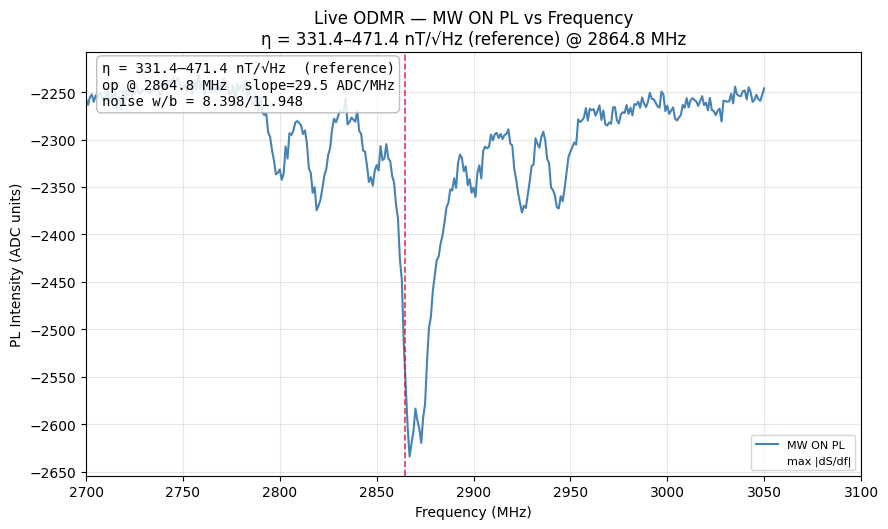

Live plot stopped.
η = 331.4–471.4 nT/√Hz  (reference) | op @ 2864.8 MHz  slope=29.5 ADC/MHz | noise w/b = 8.398/11.948


In [370]:
# Live ODMR — MW ON photoluminescence vs frequency (not contrast)
# Requires: run the ODMR configuration & acquire cell first so `prog_odmr` exists.
# Each refresh is a full sweep + structure-aware η_B (same estimator as quick_sensitivity).
# For faster updates, narrow the sweep or lower ODMR_REPS.
# Press Stop (■) to interrupt the kernel and exit.

from qickdawg.nvpulsing.nv_live_helpers import run_live_odmr

run_live_odmr(
    prog_odmr,
    xlim=(None, 3100),
    show_sensitivity=True,  # set False to skip live η overlay
)
